<a href="https://colab.research.google.com/github/Juejeet/Supervised-ML-using-IRIS-dataset./blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style='whitegrid')

In [2]:
from sklearn.datasets import load_iris

iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name='species')

species_map = dict(enumerate(iris.target_names))
y_named = y.map(species_map)

display(X.head())
display(y_named.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


,species
0,setosa
1,setosa
2,setosa
3,setosa
4,setosa


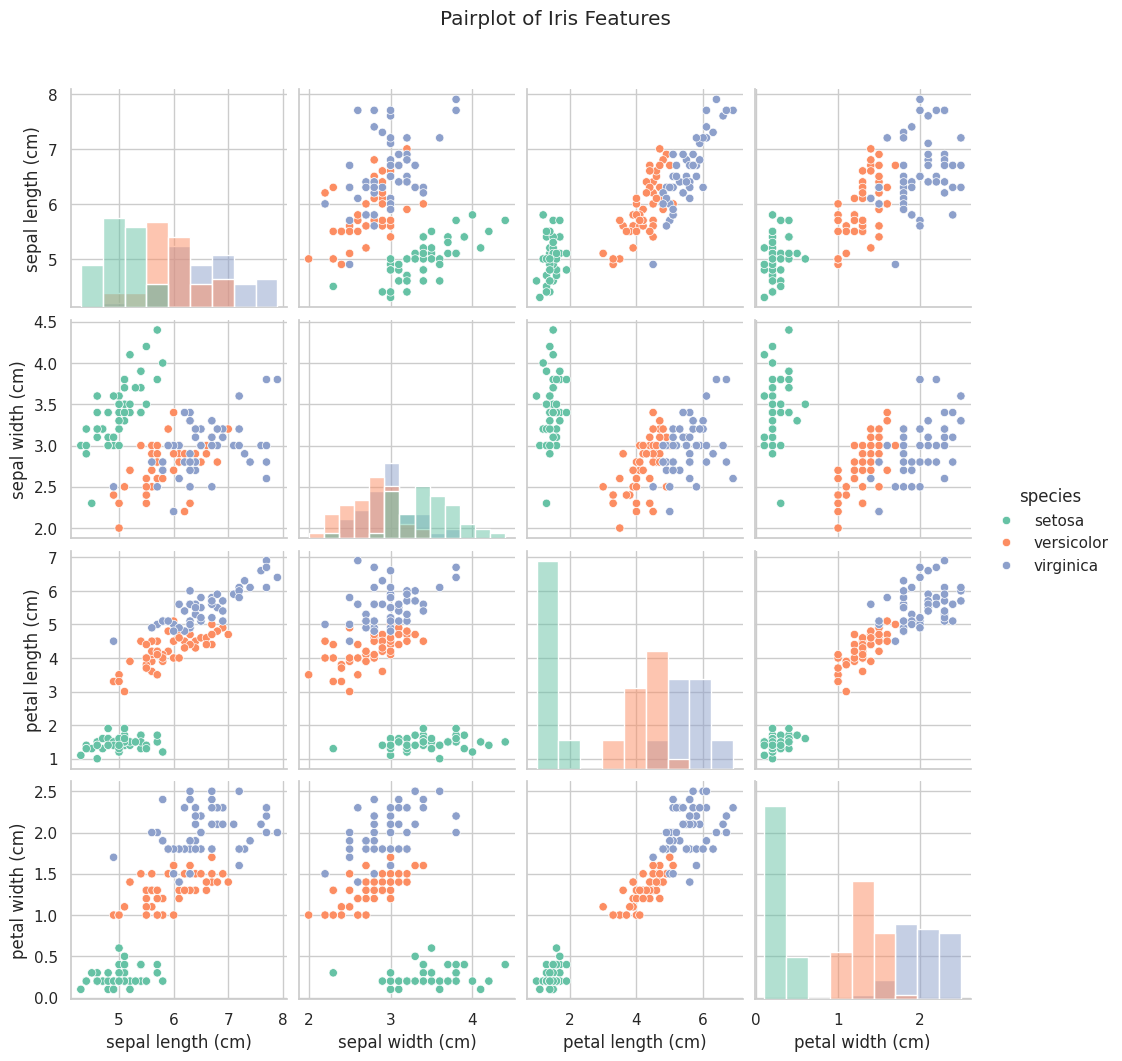

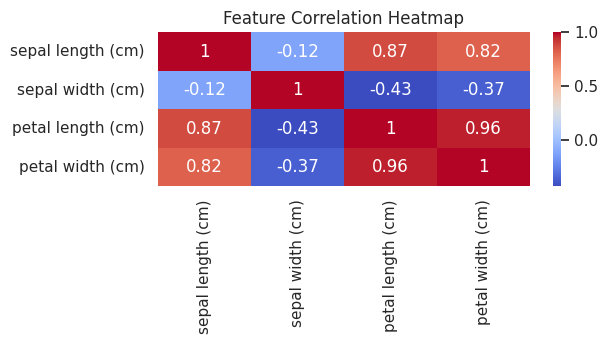

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Combine features and species into one DataFrame for visualization
df = X.copy()
df['species'] = y_named

# Pairplot (to see relationship between features)
sns.pairplot(df, hue='species', diag_kind='hist', palette='Set2')  # Softer pastel palette
plt.suptitle('Pairplot of Iris Features', y=1.06)
plt.show()

# Correlation Heatmap
plt.figure(figsize=(6,2))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')  # Contrasting red-blue heatmap
plt.title('Feature Correlation Heatmap')
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

# Scale features (standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (90, 4)
Testing data shape: (60, 4)


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Train multiple models
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(random_state=50),
    "Random Forest": RandomForestClassifier(random_state=60)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    print(f"{name}: Accuracy = {acc:.2f}")

Logistic Regression: Accuracy = 0.93
Decision Tree: Accuracy = 0.97
Random Forest: Accuracy = 0.93


Model Accuracy: 91.67%

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        20
  versicolor       0.83      0.95      0.88        20
   virginica       0.94      0.80      0.86        20

    accuracy                           0.92        60
   macro avg       0.92      0.92      0.92        60
weighted avg       0.92      0.92      0.92        60



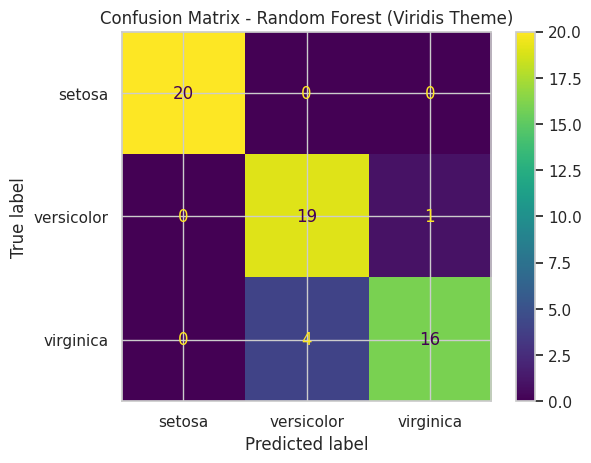

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Train and predict
best_model = RandomForestClassifier(random_state=42)
best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)

# Accuracy and classification report
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy*100:.2f}%")  # Changed accuracy format to percentage with 2 decimals
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=iris.target_names))

# Confusion matrix visualization with different color
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap='viridis')  # Changed color scheme here
plt.title('Confusion Matrix - Random Forest (Viridis Theme)')
plt.show()